In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("candor_dataset_clean.csv")

cols = [
    "call_id",
    "pauses_actor", "pauses_partner",
    "how_enjoyable_actor", "how_enjoyable_partner",
    # kontroller:
    "tfo_actor","tfo_partner",
    "overlap_actor","overlap_partner",
    "speech_activity_actor","speech_activity_partner",
    "conv_length_actor","conv_length_partner",
]
df = df[cols]

print(df.shape)
df.head()

(3202, 13)


,call_id,pauses_actor,pauses_partner,how_enjoyable_actor,how_enjoyable_partner,tfo_actor,tfo_partner,overlap_actor,overlap_partner,speech_activity_actor,speech_activity_partner,conv_length_actor,conv_length_partner
0,dd9b5c4a-19cb-4af3-b0e8-f1ce12c5b8fe,0.198,0.134,6.0,9.0,0.246,0.158,0.019,0.030,0.453,0.360,32.0,30.0
1,dd9b5c4a-19cb-4af3-b0e8-f1ce12c5b8fe,0.134,0.198,9.0,6.0,0.158,0.246,0.030,0.019,0.360,0.453,30.0,32.0
2,dbe27cbe-5693-4994-b281-d481a5a4e1f0,0.180,0.167,5.0,9.0,0.330,0.152,0.066,0.058,0.416,0.399,28.0,29.0
3,dbe27cbe-5693-4994-b281-d481a5a4e1f0,0.167,0.180,9.0,5.0,0.152,0.330,0.058,0.066,0.399,0.416,29.0,28.0
4,3edbfb87-6b83-4dd0-a4d8-09ca1eba6a3e,0.243,0.154,5.0,5.0,0.137,0.272,0.014,0.019,0.373,0.414,27.0,28.0


In [ ]:
# null-check
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0])

# Dropna
df = df.dropna().copy()
print(df.shape)

Series([], dtype: float64)
(3202, 13)


In [ ]:
# Dyad-level aggregation
dyad = df.groupby("call_id", as_index=False).agg({
    "pauses_actor": "mean",
    "pauses_partner": "mean",
    "how_enjoyable_actor": "mean",
    "how_enjoyable_partner": "mean",
    "tfo_actor": "mean",
    "tfo_partner": "mean",
    "overlap_actor": "mean",
    "overlap_partner": "mean",
    "speech_activity_actor": "mean",
    "speech_activity_partner": "mean",
    "conv_length_actor": "mean",
    "conv_length_partner": "mean",
})

# dyad features
dyad["MeanPause"] = dyad[["pauses_actor", "pauses_partner"]].mean(axis=1)
dyad["MutualEnjoyment"] = dyad[["how_enjoyable_actor", "how_enjoyable_partner"]].mean(axis=1)

# dyad-kontroller
dyad["MeanTFO"] = dyad[["tfo_actor", "tfo_partner"]].mean(axis=1)
dyad["MeanOverlap"] = dyad[["overlap_actor", "overlap_partner"]].mean(axis=1)
dyad["MeanSpeechActivity"] = dyad[["speech_activity_actor", "speech_activity_partner"]].mean(axis=1)
dyad["MeanConvLength"] = dyad[["conv_length_actor", "conv_length_partner"]].mean(axis=1)

dyad[["call_id","MeanPause","MutualEnjoyment","MeanTFO","MeanOverlap","MeanSpeechActivity","MeanConvLength"]].head()

,call_id,MeanPause,MutualEnjoyment,MeanTFO,MeanOverlap,MeanSpeechActivity,MeanConvLength
0,0020a0c5-1658-4747-99c1-2839e736b481,0.1610,8.5,0.4355,0.0525,0.3975,44.0
1,002d68da-7738-4177-89d9-d72ae803e0e4,0.1825,8.0,0.3460,0.0270,0.3950,34.0
2,00411458-8275-4b92-a000-d52187f03604,0.1340,7.5,0.2015,0.0515,0.4150,35.0
3,00ae2f18-9599-4df6-8e3a-6936c86b97f0,0.2090,8.0,0.2790,0.0405,0.3675,32.5
4,00b410f7-8b5f-4404-8433-0fb8c4be8f62,0.2840,7.0,0.3335,0.0455,0.3245,30.0


In [5]:
from scipy.stats import pearsonr, spearmanr

x = dyad["MeanPause"]
y = dyad["MutualEnjoyment"]

r_p, p_p = pearsonr(x, y)
r_s, p_s = spearmanr(x, y)

print(f"Pearson r = {r_p:.3f}, p = {p_p:.4g}")
print(f"Spearman ρ = {r_s:.3f}, p = {p_s:.4g}")

Pearson r = -0.123, p = 8.771e-07
Spearman ρ = -0.130, p = 1.786e-07


In [7]:
import sys
!{sys.executable} -m pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 10.5 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import statsmodels.api as sm

X = sm.add_constant(dyad["MeanPause"])
model = sm.OLS(dyad["MutualEnjoyment"], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        MutualEnjoyment   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     24.37
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           8.77e-07
Time:                        14:24:41   Log-Likelihood:                -2518.0
No. Observations:                1601   AIC:                             5040.
Df Residuals:                    1599   BIC:                             5051.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.8127      0.087     89.888      0.0

In [9]:
X = dyad[["MeanPause","MeanTFO","MeanOverlap","MeanSpeechActivity","MeanConvLength"]].copy()
X = sm.add_constant(X)

model_ctrl = sm.OLS(dyad["MutualEnjoyment"], X).fit()
print(model_ctrl.summary())

                            OLS Regression Results                            
Dep. Variable:        MutualEnjoyment   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     19.05
Date:                Sun, 01 Mar 2026   Prob (F-statistic):           1.90e-18
Time:                        14:25:01   Log-Likelihood:                -2483.6
No. Observations:                1601   AIC:                             4979.
Df Residuals:                    1595   BIC:                             5012.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  5.3598      1

In [10]:
dyad["MeanPause"].describe(percentiles=[.95,.99])

count    1601.00000
mean        0.19322
std         0.06885
min         0.05250
50%         0.18150
95%         0.31800
99%         0.39400
max         0.73900
Name: MeanPause, dtype: float64

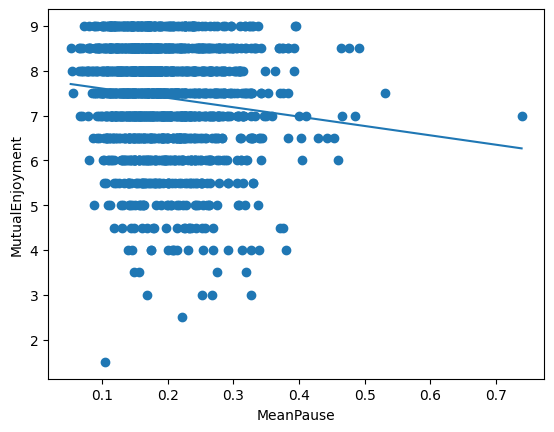

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = dyad["MeanPause"].values
y = dyad["MutualEnjoyment"].values

plt.figure()
plt.scatter(x, y)

# linjär fit för visualisering
m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, m*xx + b)

plt.xlabel("MeanPause")
plt.ylabel("MutualEnjoyment")
plt.show()

In [12]:
dyad.to_csv("../data/processed/candor_dyad_clean.csv", index=False)
print(dyad.shape)

OSError: Cannot save file into a non-existent directory: '../data/processed'